# Preserve georef when cropping (COG)

Do **not** save the crop as PNG (`imageio` / PIL) — that drops CRS/transform. Crop with rasterio and write a GeoTIFF (`crs` + `transform`), then POST it. The API returns a georeferenced road mask COG.

Requires `make run-cpu`.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import rasterio as rio
from rasterio.plot import show as rio_show
from rasterio.windows import Window
from rasterio.warp import transform_bounds

source = Path("samples/Milan/sentinel-2-l2a_2025-12-26.tiff")
out_dir = Path("outputs/georef_crop_demo")
out_dir.mkdir(parents=True, exist_ok=True)
rgb_full = out_dir / "milan_rgb_full.tif"
rgb_crop = out_dir / "milan_rgb_center_crop.tif"
crop_size = 256

# RGB GeoTIFF (keep georef) — not PNG
with rio.open(source) as src:
    rgb = np.clip(src.read((4, 3, 2)) / 4000, 0, 1)
    rgb = (rgb * 255).astype(np.uint8)
    profile = src.profile.copy()
    profile.update(driver="GTiff", count=3, dtype="uint8", compress="deflate")
    for k in ("blockxsize", "blockysize", "tiled", "interleave"):
        profile.pop(k, None)
    with rio.open(rgb_full, "w", **profile) as dst:
        dst.write(rgb)

# center crop with updated transform (same idea as rasterio.mask out_transform)
with rio.open(rgb_full) as src:
    size = min(crop_size, src.height, src.width)
    window = Window((src.width - size) // 2, (src.height - size) // 2, size, size)
    data = src.read(window=window)
    transform = src.window_transform(window)
    profile = src.profile.copy()
    profile.update(height=size, width=size, transform=transform)
    with rio.open(rgb_crop, "w", **profile) as dst:
        dst.write(data)

print("full :", rgb_full)
print("crop :", rgb_crop, f"({size}x{size})")

full : outputs/georef_crop_demo/milan_rgb_full.tif
crop : outputs/georef_crop_demo/milan_rgb_center_crop.tif (256x256)


full EPSG:4326 lon[9.13381,9.20177] lat[45.43072,45.46185]
crop EPSG:4326 lon[9.15134,9.18411] lat[45.43485,45.45782]


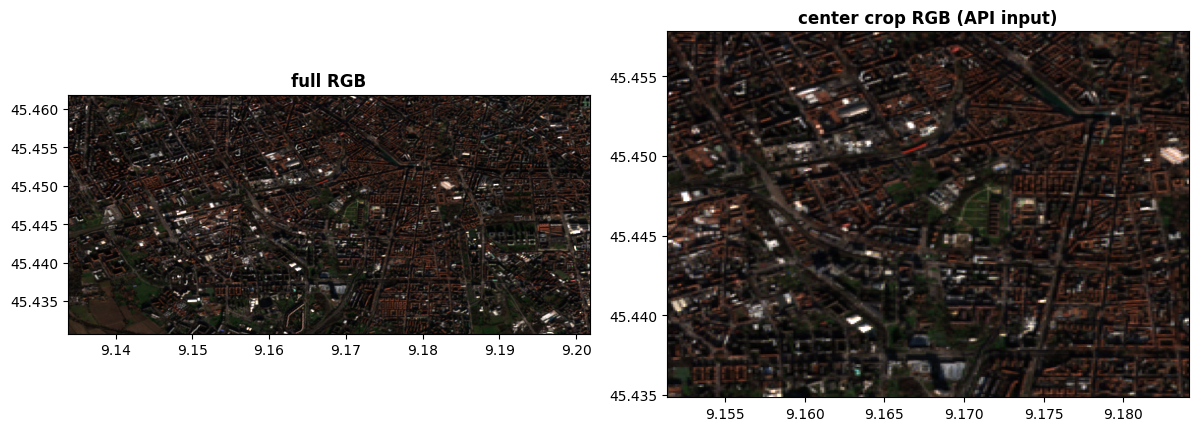

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

with rio.open(rgb_full) as src:
    rio_show(src, ax=axes[0], title="full RGB")
    w, s, e, n = transform_bounds(src.crs, "EPSG:4326", *src.bounds)
    print("full", src.crs, f"lon[{w:.5f},{e:.5f}] lat[{s:.5f},{n:.5f}]")

with rio.open(rgb_crop) as src:
    rio_show(src, ax=axes[1], title="center crop RGB (API input)")
    w, s, e, n = transform_bounds(src.crs, "EPSG:4326", *src.bounds)
    print("crop", src.crs, f"lon[{w:.5f},{e:.5f}] lat[{s:.5f},{n:.5f}]")

plt.tight_layout()
plt.show()

input  EPSG:4326 BoundingBox(left=9.151341935969867, bottom=45.43484727377521, right=9.184106079096043, top=45.45781644956772)
output EPSG:4326 BoundingBox(left=9.151341935969867, bottom=45.43484727377521, right=9.184106079096043, top=45.45781644956772)
WGS84 lon[9.15134,9.18411] lat[45.43485,45.45782]


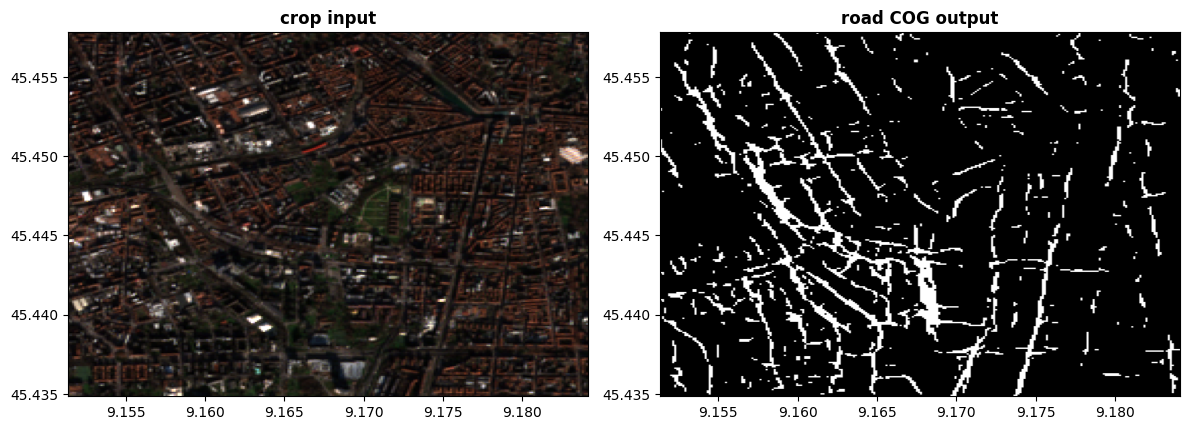

In [4]:
import requests

url = "http://localhost:8000/MassachusettsRoadsS2Model"
# url = "https://eotdl.dev.gda.adamplatform.eu/MassachusettsRoadsS2Model"
headers = {"X-API-Key": "123"}

res = requests.post(url, files={"image": open(rgb_crop, "rb")}, headers=headers)
assert res.status_code == 200, res.text

mask_cog = out_dir / "milan_roads_crop_cog.tif"
mask_cog.write_bytes(res.content)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
with rio.open(rgb_crop) as src:
    rio_show(src, ax=axes[0], title="crop input")
    print("input ", src.crs, src.bounds)

with rio.open(mask_cog) as src:
    rio_show(src, ax=axes[1], title="road COG output", cmap="gray", vmin=0, vmax=1)
    w, s, e, n = transform_bounds(src.crs, "EPSG:4326", *src.bounds)
    print("output", src.crs, src.bounds)
    print(f"WGS84 lon[{w:.5f},{e:.5f}] lat[{s:.5f},{n:.5f}]")

plt.tight_layout()
plt.show()

### Your pipeline fix

Instead of:
```python
out_image, out_transform = rasteriomask(ds, [geom], crop=True)
imageio.imwrite("..._cut.png", np.transpose(out_image, (1, 2, 0)))  # loses georef
```

Do:
```python
out_image, out_transform = rasteriomask(ds, [geom], crop=True)
with rio.open(path, "w", driver="GTiff",
              height=out_image.shape[1], width=out_image.shape[2],
              count=out_image.shape[0], dtype=out_image.dtype,
              crs=ds.crs, transform=out_transform) as dst:
    dst.write(out_image)
# POST the .tif — not a .png
```